# AED  Predicción de Severidad de Accidentes Ciclistas

**Objetivo:** Clasificación multiclase de severidad de accidentes con ciclistas  
**Variable objetivo:** `severity_code` (1 = fatal, 2 = lesion, 4 = danios materiales)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

RUTA = 'dataset/'


## 1. Carga de todos los datasets

In [2]:
acc = pd.read_csv(RUTA + 'accidents.csv', low_memory=False, na_values=['\\N'])
summary = pd.read_csv(RUTA + 'gemeente_yearly_summary.csv')

print(f'accidents:                {acc.shape}')
print(f'gemeente_yearly_summary:  {summary.shape}')
print()
print('El summary ya contiene integrados: clima, infraestructura, población')


accidents:                (56743, 27)
gemeente_yearly_summary:  (3420, 24)

El summary ya contiene integrados: clima, infraestructura, población


## 2. Integración → Tabla minable unificada

### 2.1 Merge: accidentes + resumen anual

El `gemeente_yearly_summary` ya consolida por municipio/año:
- **Infraestructura:** km de ciclovías, carriles, estacionamientos
- **Clima:** temperatura media, precipitación anual, horas sol
- **Población:** habitantes, densidad
- **Siniestros:** conteo total, fatales, lesiones graves

Las tablas `weather_daily`, `weather_stations`, `cycling_infrastructure_osm` y `gemeenten` son la **fuente original** con que se construyó este summary. Como `accidents` solo tiene `year` (sin fecha exacta), no podemos hacer join a nivel de día.

In [3]:
acc['year'] = acc['year'].astype(int)

summary_cols = ['gemeente_code', 'year', 'km_cycleway', 'km_track', 'km_lane', 'km_total',
                'bicycle_parking_count', 'population', 'population_density_km2',
                'weather_mean_temp_mean_c', 'weather_mean_temp_min_c',
                'weather_mean_temp_max_c', 'weather_mean_humidity_pct',
                'weather_mean_pressure_hpa', 'weather_annual_precip_mm',
                'weather_annual_sunshine_hours']

df = acc.merge(summary[summary_cols], on=['gemeente_code', 'year'], how='left')
print(f'Shape tras merge: {df.shape}')
print(f'Sin match en summary: {df["km_total"].isna().sum()}')
# speed_limit_kmh: \N -> NaN -> numerico
df['speed_limit_kmh'] = pd.to_numeric(df['speed_limit_kmh'], errors='coerce')


Shape tras merge: (56743, 41)
Sin match en summary: 1118


In [4]:
print('=== Validación post-merge ===')
expected_rows = 56743
assert len(df) == expected_rows, f'Filas cambiaron: {len(df)} vs {expected_rows}'
assert df['severity_code'].isin([1, 2, 4]).all(), 'severity_code contiene valores inesperados'
assert 'gemeente_code' in df.columns, 'Merge falló: gemeente_code ausente'

print(f'Filas: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'speed_limit_kmh dtype: {df["speed_limit_kmh"].dtype}')
print(f'speed_limit_kmh nulos: {df["speed_limit_kmh"].isna().sum():,}')


=== Validación post-merge ===
Filas: 56,743
Columnas: 41
speed_limit_kmh dtype: float64
speed_limit_kmh nulos: 3,261


In [5]:
print('Columnas disponibles:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')


Columnas disponibles:
   1. accident_id
   2. year
   3. severity_raw
   4. party_count
   5. party1_type
   6. party2_type
   7. accident_type
   8. road_situation
   9. speed_limit_kmh
  10. road_lighting
  11. light_condition_label
  12. weather_raw
  13. infra_type
  14. road_segment_id
  15. street_name
  16. place_name
  17. gemeente_name_raw
  18. province
  19. alcohol_indicated
  20. latitude
  21. longitude
  22. severity_label
  23. severity_code
  24. weather_label
  25. built_up_area
  26. cyclists_involved
  27. gemeente_code
  28. km_cycleway
  29. km_track
  30. km_lane
  31. km_total
  32. bicycle_parking_count
  33. population
  34. population_density_km2
  35. weather_mean_temp_mean_c
  36. weather_mean_temp_min_c
  37. weather_mean_temp_max_c
  38. weather_mean_humidity_pct
  39. weather_mean_pressure_hpa
  40. weather_annual_precip_mm
  41. weather_annual_sunshine_hours


## 3. AED sobre la tabla unificada

### 3.1 Variable objetivo —`severity_code`

=== Distribución de severidad ===
  Fatal (1):    573 (1.01%)
  Lesión (2): 30,334 (53.46%)
  Daños materiales (4): 25,836 (45.53%)


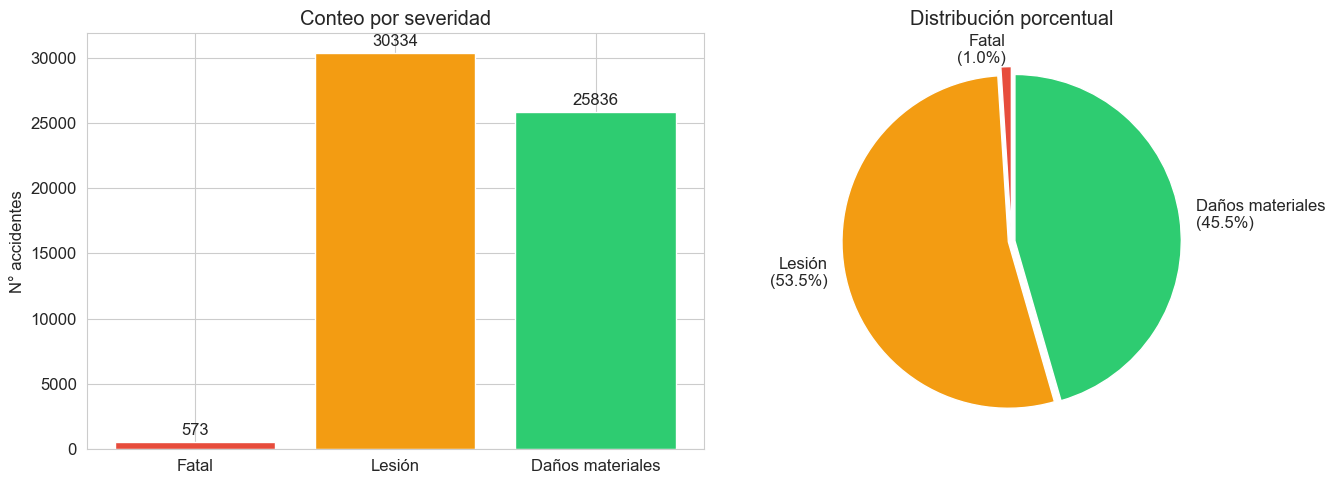

In [6]:
labels = {1: 'Fatal', 2: 'Lesión', 4: 'Daños materiales'}
sev_dist = df['severity_code'].value_counts().sort_index()
sev_pct = df['severity_code'].value_counts(normalize=True).sort_index() * 100

print('=== Distribución de severidad ===')
for code in [1, 2, 4]:
    print(f'  {labels[code]} ({code}): {sev_dist[code]:>6,} ({sev_pct[code]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[0].bar([labels[c] for c in [1,2,4]], sev_dist.values, color=colors)
axes[0].bar_label(bars, padding=3)
axes[0].set_title('Conteo por severidad')
axes[0].set_ylabel('N° accidentes')

axes[1].pie(sev_dist.values, labels=[f'{labels[c]}\n({sev_pct[c]:.1f}%)' for c in [1,2,4]],
            colors=colors, startangle=90, explode=(0.05, 0.02, 0.02))
axes[1].set_title('Distribución porcentual')
plt.tight_layout()
plt.show()


### 3.2 Análisis univariado  —  variables numéricas

In [7]:
num_cols = ['party_count', 'speed_limit_kmh', 'year',
            'km_total', 'km_cycleway', 'population_density_km2',
            'weather_mean_temp_mean_c', 'weather_annual_precip_mm', 'weather_annual_sunshine_hours']

df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
party_count,56743.0,1.939993,0.484009,1.000,2.000,2.000,2.000,12.000
speed_limit_kmh,53482.0,44.063797,12.622633,15.000,30.000,50.000,50.000,130.000
year,56743.0,2023.024073,0.816768,2022.000,2022.000,2023.000,2024.000,2024.000
km_total,55625.0,380.695191,384.817188,10.105,126.339,237.350,456.340,1465.201
km_cycleway,55625.0,351.671111,361.847984,8.686,116.361,213.722,413.593,1368.957
population_density_km2,55625.0,2270.547991,2038.008360,23.000,584.000,1468.000,3542.000,6868.000
weather_mean_temp_mean_c,4643.0,11.792417,0.404549,10.760,11.530,11.880,12.090,12.540
weather_annual_precip_mm,4942.0,893.176932,307.190877,0.000,764.700,990.700,1052.900,1994.700
weather_annual_sunshine_hours,4942.0,1869.621145,637.922642,0.000,1757.800,1883.300,2171.800,4342.300


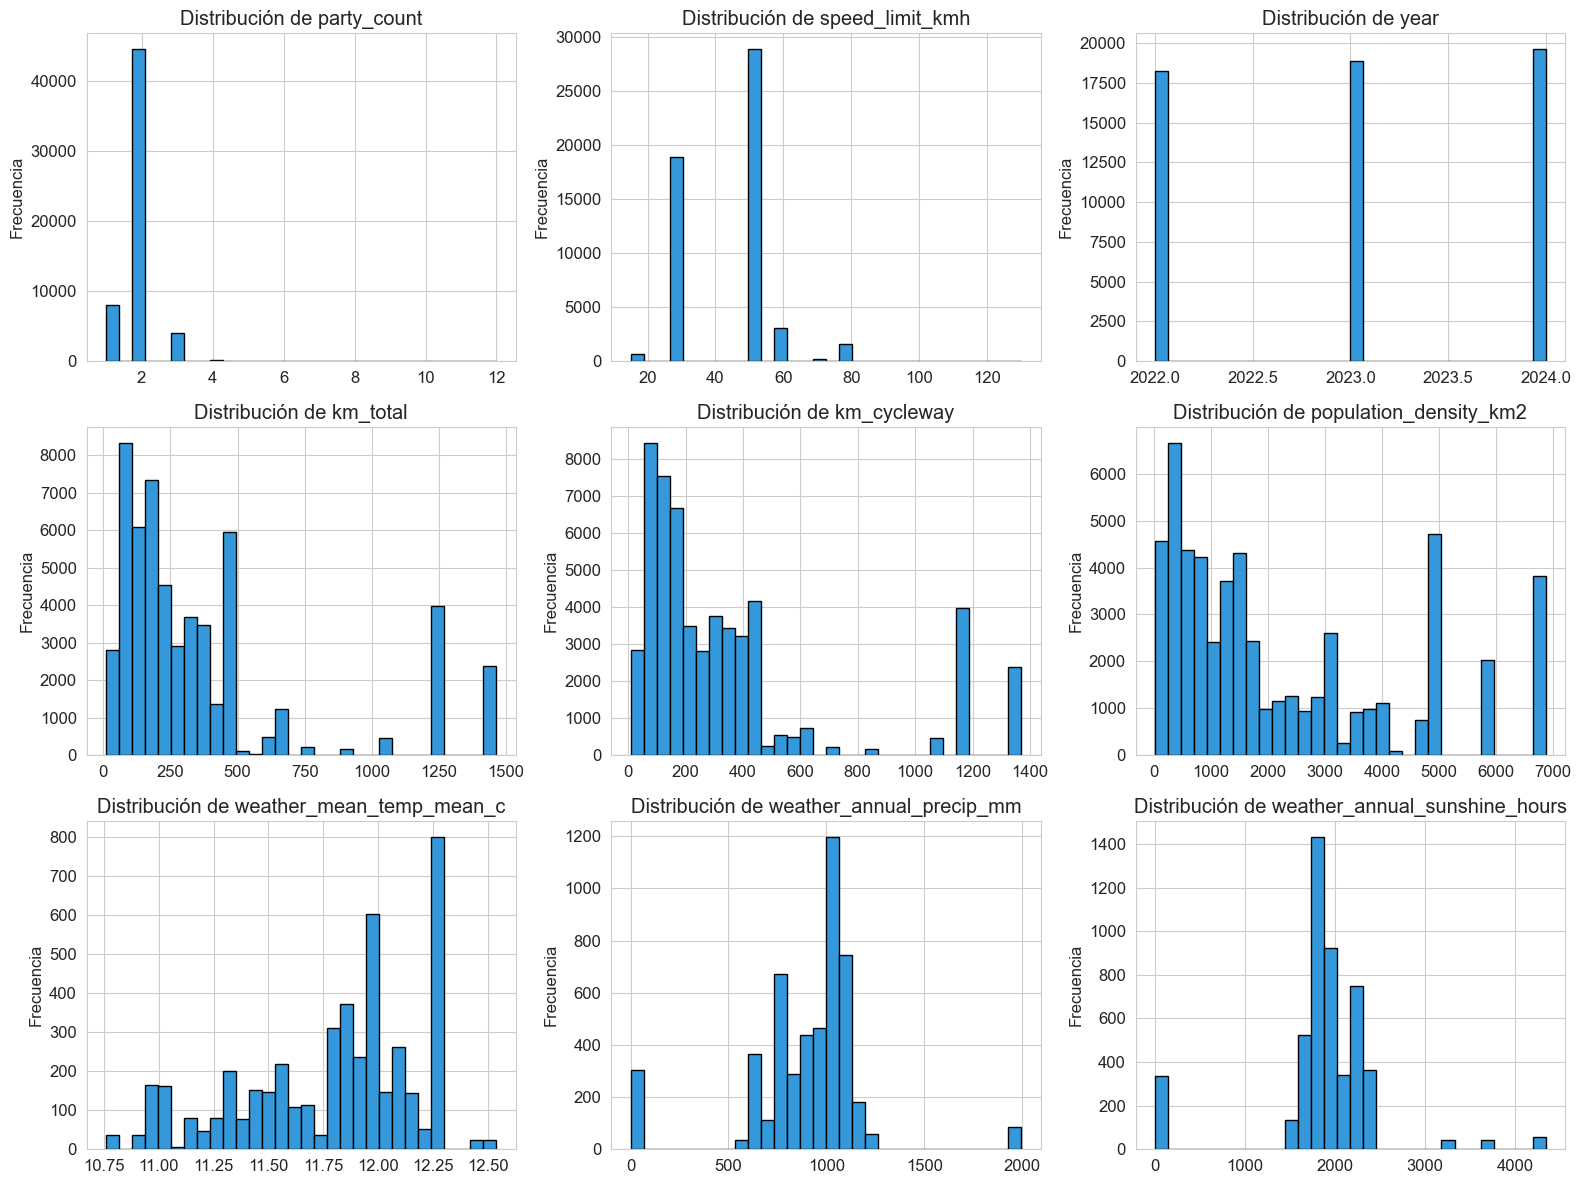

In [8]:
n = len(num_cols)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(16, rows * 4))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', color='#3498db')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Frecuencia')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


### 3.3 Análisis univariado  —  variables categóricas

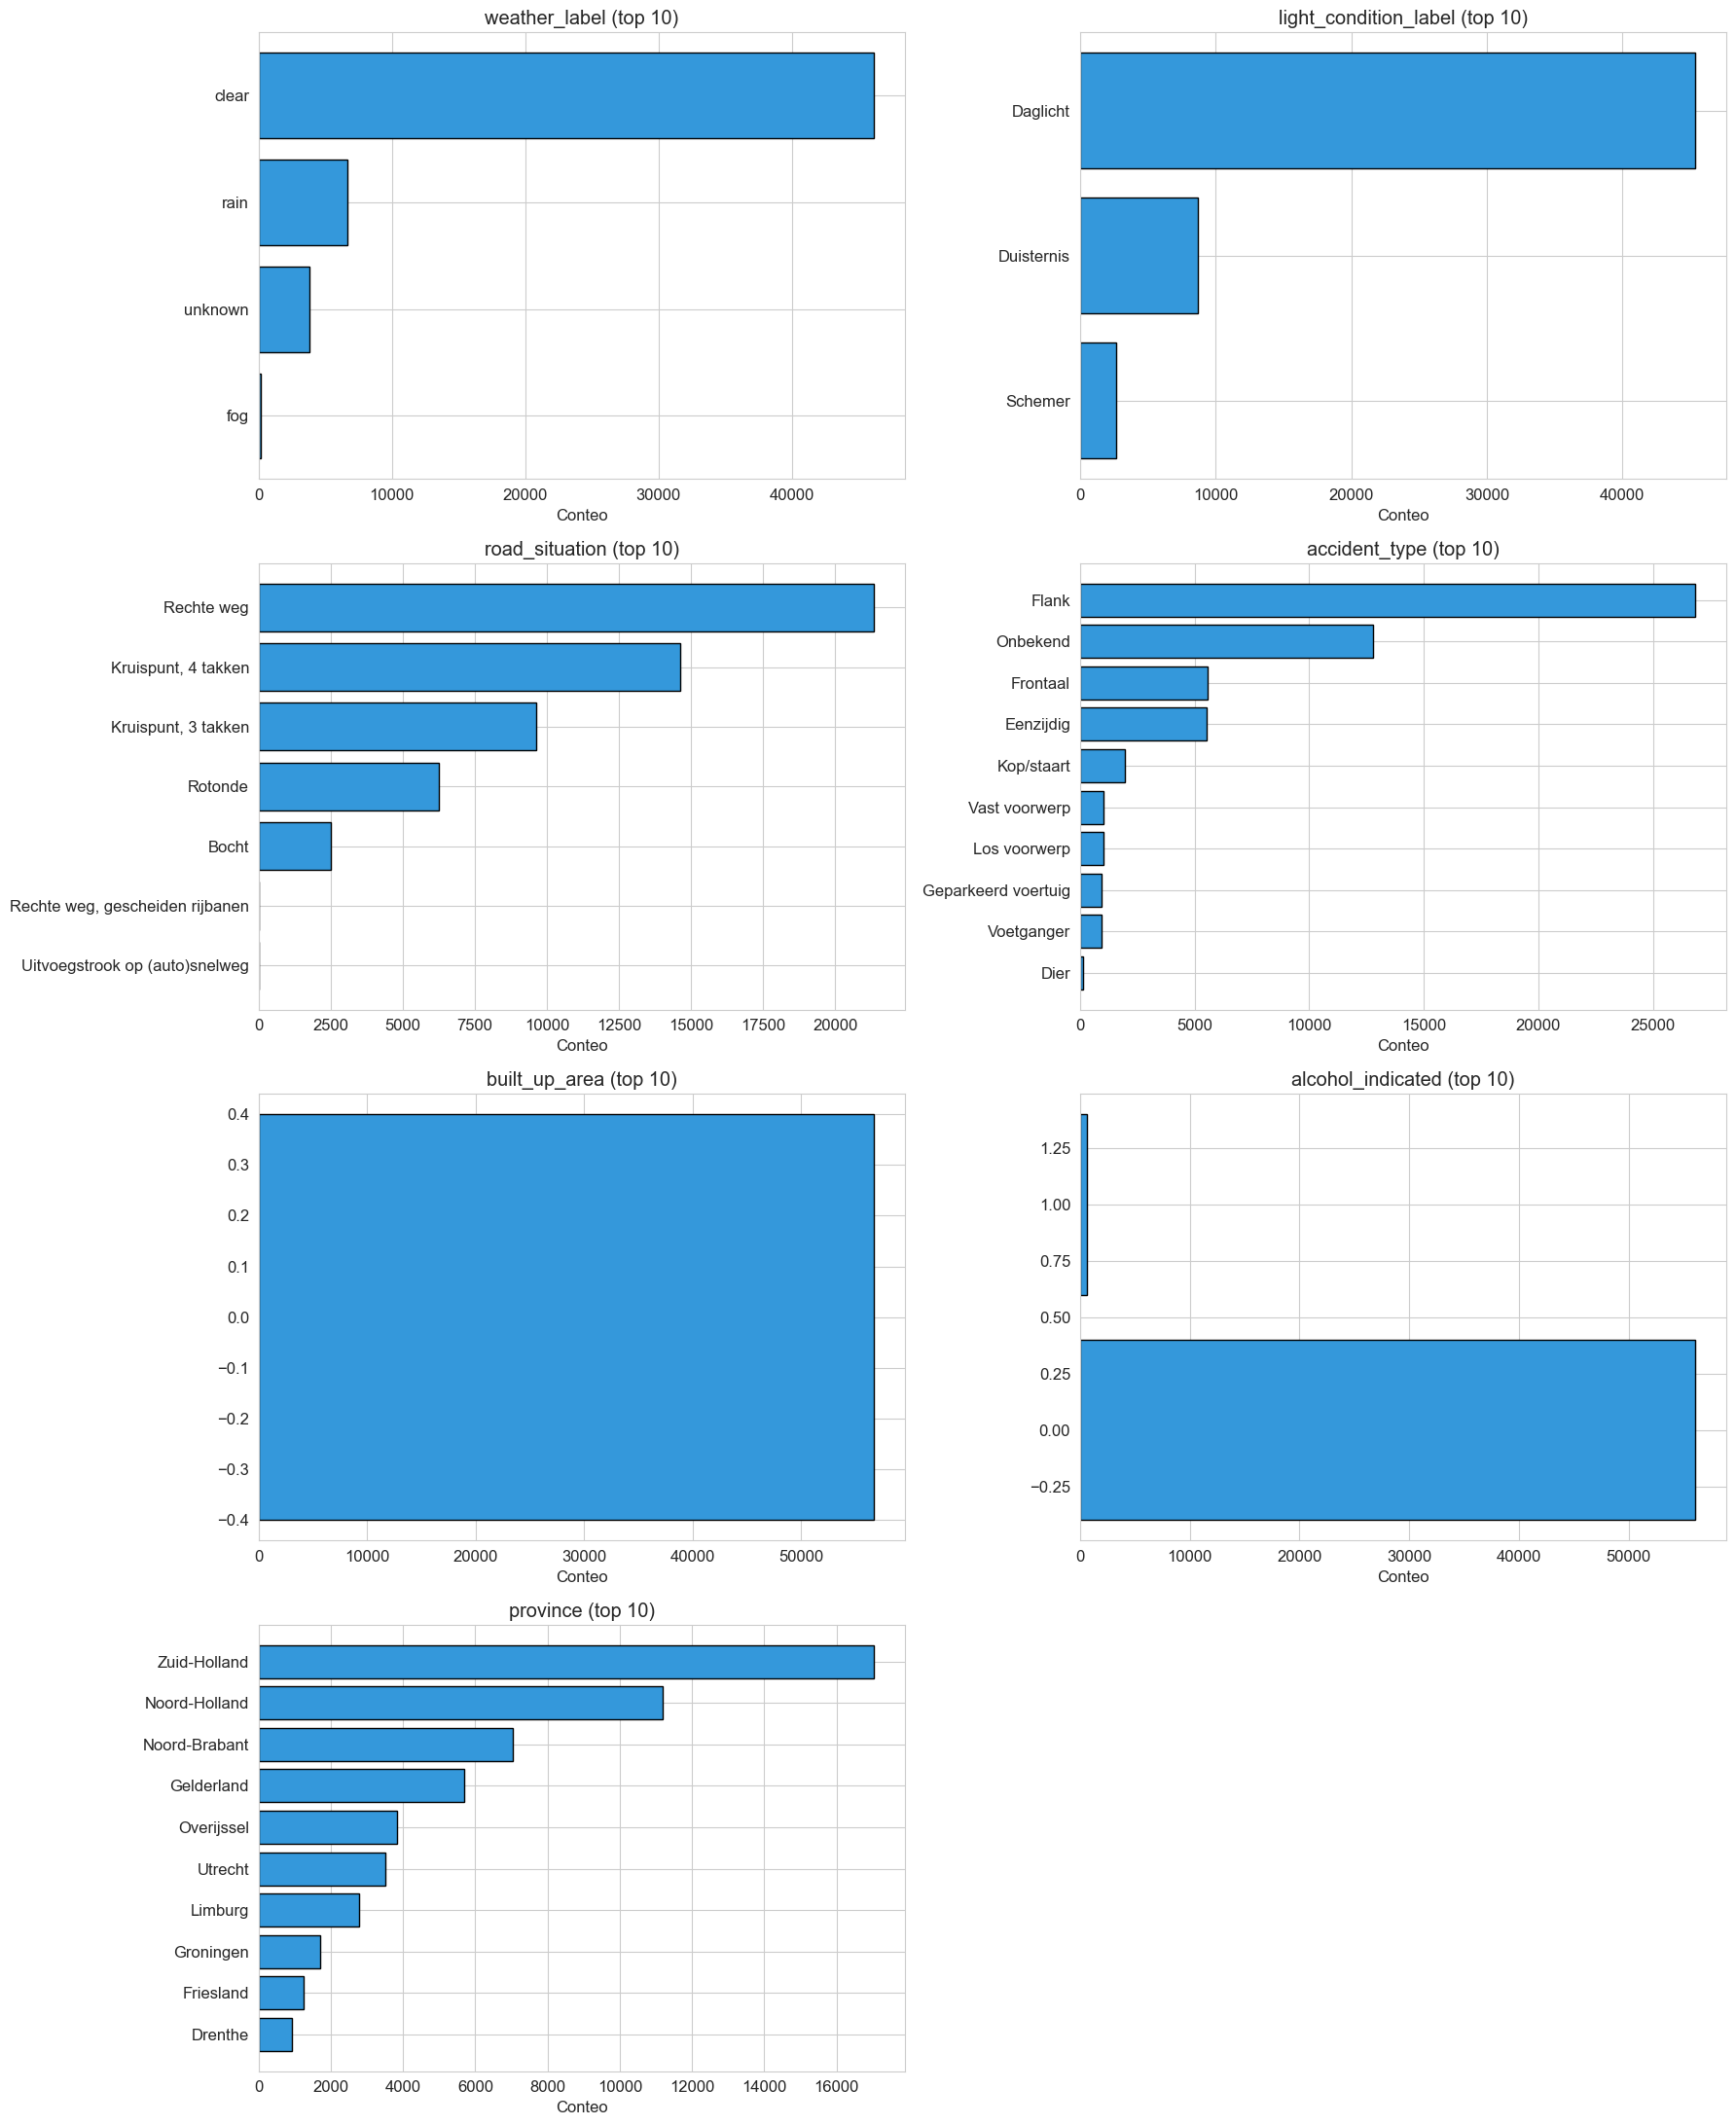

In [9]:
cat_cols = ['weather_label', 'light_condition_label', 'road_situation',
            'accident_type', 'built_up_area', 'alcohol_indicated', 'province']

fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts().head(10)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color='#3498db', edgecolor='black')
    axes[i].set_title(f'{col} (top 10)')
    axes[i].set_xlabel('Conteo')
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()


### 3.4 Análisis bivariado  —  numéricas vs severidad

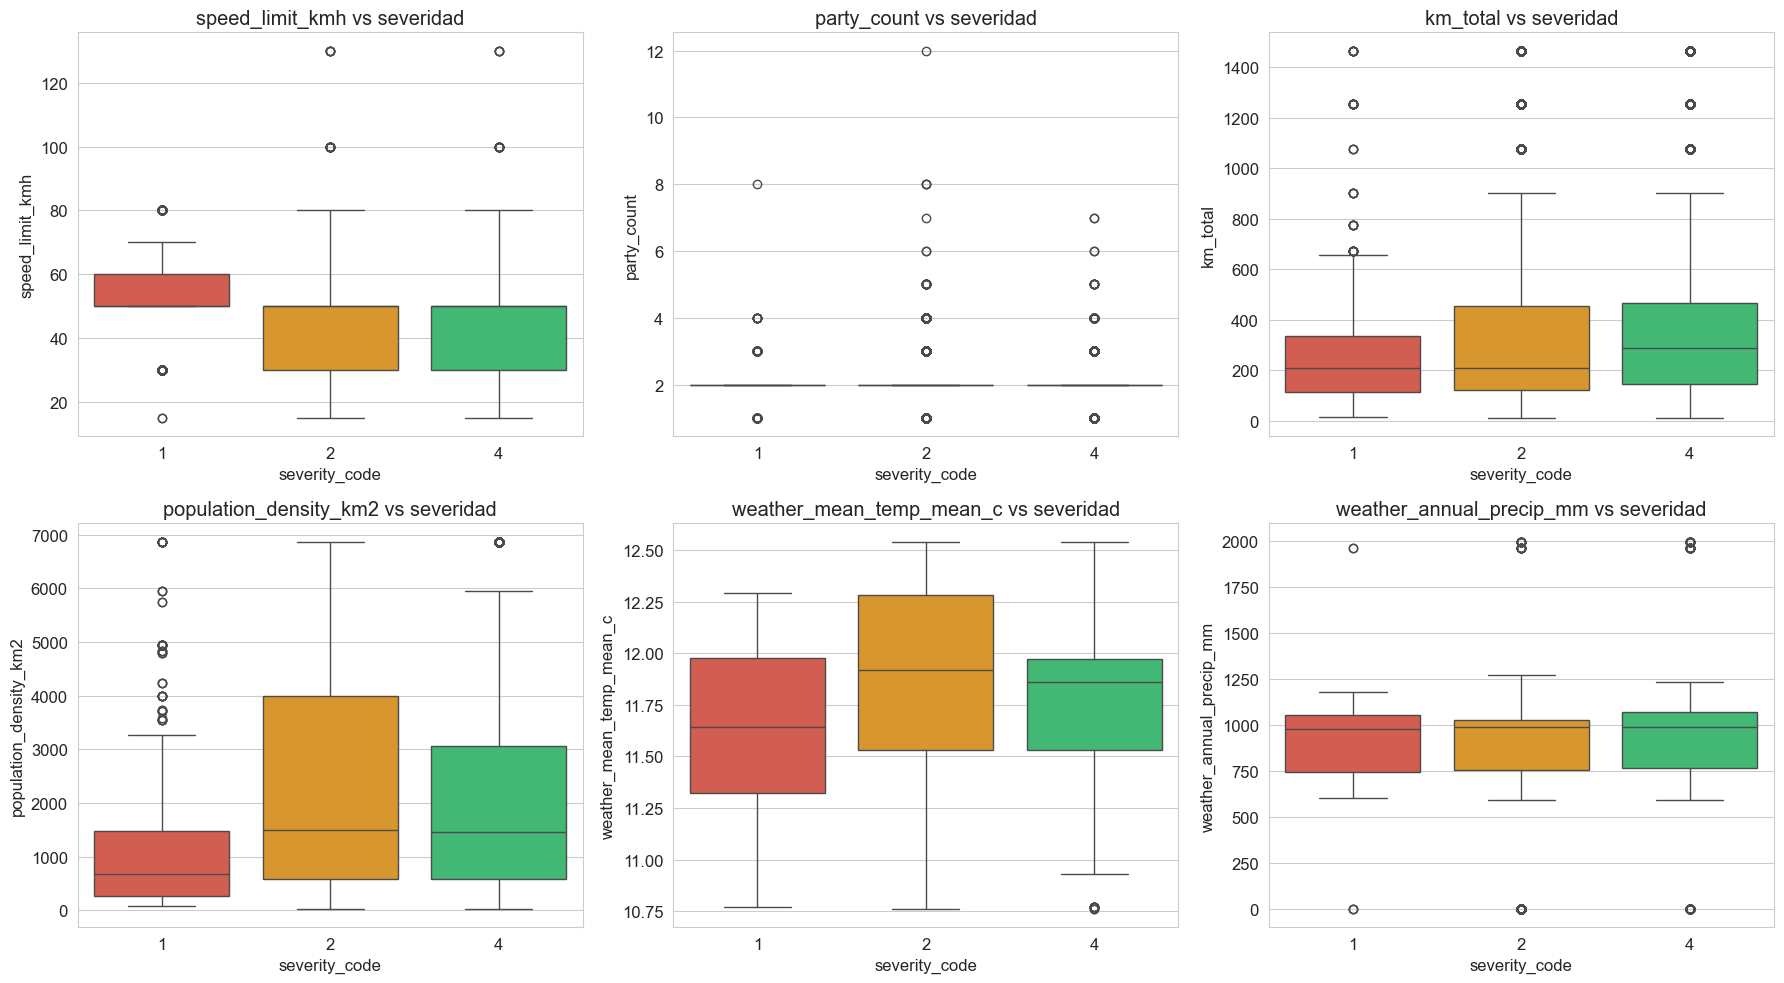

In [10]:
num_biv = ['speed_limit_kmh', 'party_count', 'km_total', 'population_density_km2',
           'weather_mean_temp_mean_c', 'weather_annual_precip_mm']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_biv):
    sns.boxplot(data=df, x='severity_code', y=col, ax=axes[i],
                palette=['#e74c3c', '#f39c12', '#2ecc71'],
                hue='severity_code', legend=False,
                order=[1, 2, 4])
    axes[i].set_title(f'{col} vs severidad')
plt.tight_layout()
plt.show()


In [11]:
print('=== Promedios por severidad ===')
num_biv = ['speed_limit_kmh', 'party_count', 'km_total', 'population_density_km2',
           'weather_mean_temp_mean_c', 'weather_annual_precip_mm']
df.groupby('severity_code')[num_biv].mean().T


=== Promedios por severidad ===


severity_code,1,2,4
speed_limit_kmh,51.725979,44.326967,43.577652
party_count,2.064572,1.888574,1.997600
km_total,298.904936,349.989061,418.269141
population_density_km2,1274.532143,2448.024839,2085.714791
weather_mean_temp_mean_c,11.650508,11.825667,11.758134
weather_annual_precip_mm,896.206452,867.482685,924.237035


### 3.5 Análisis bivariado  —  categóricas vs severidad

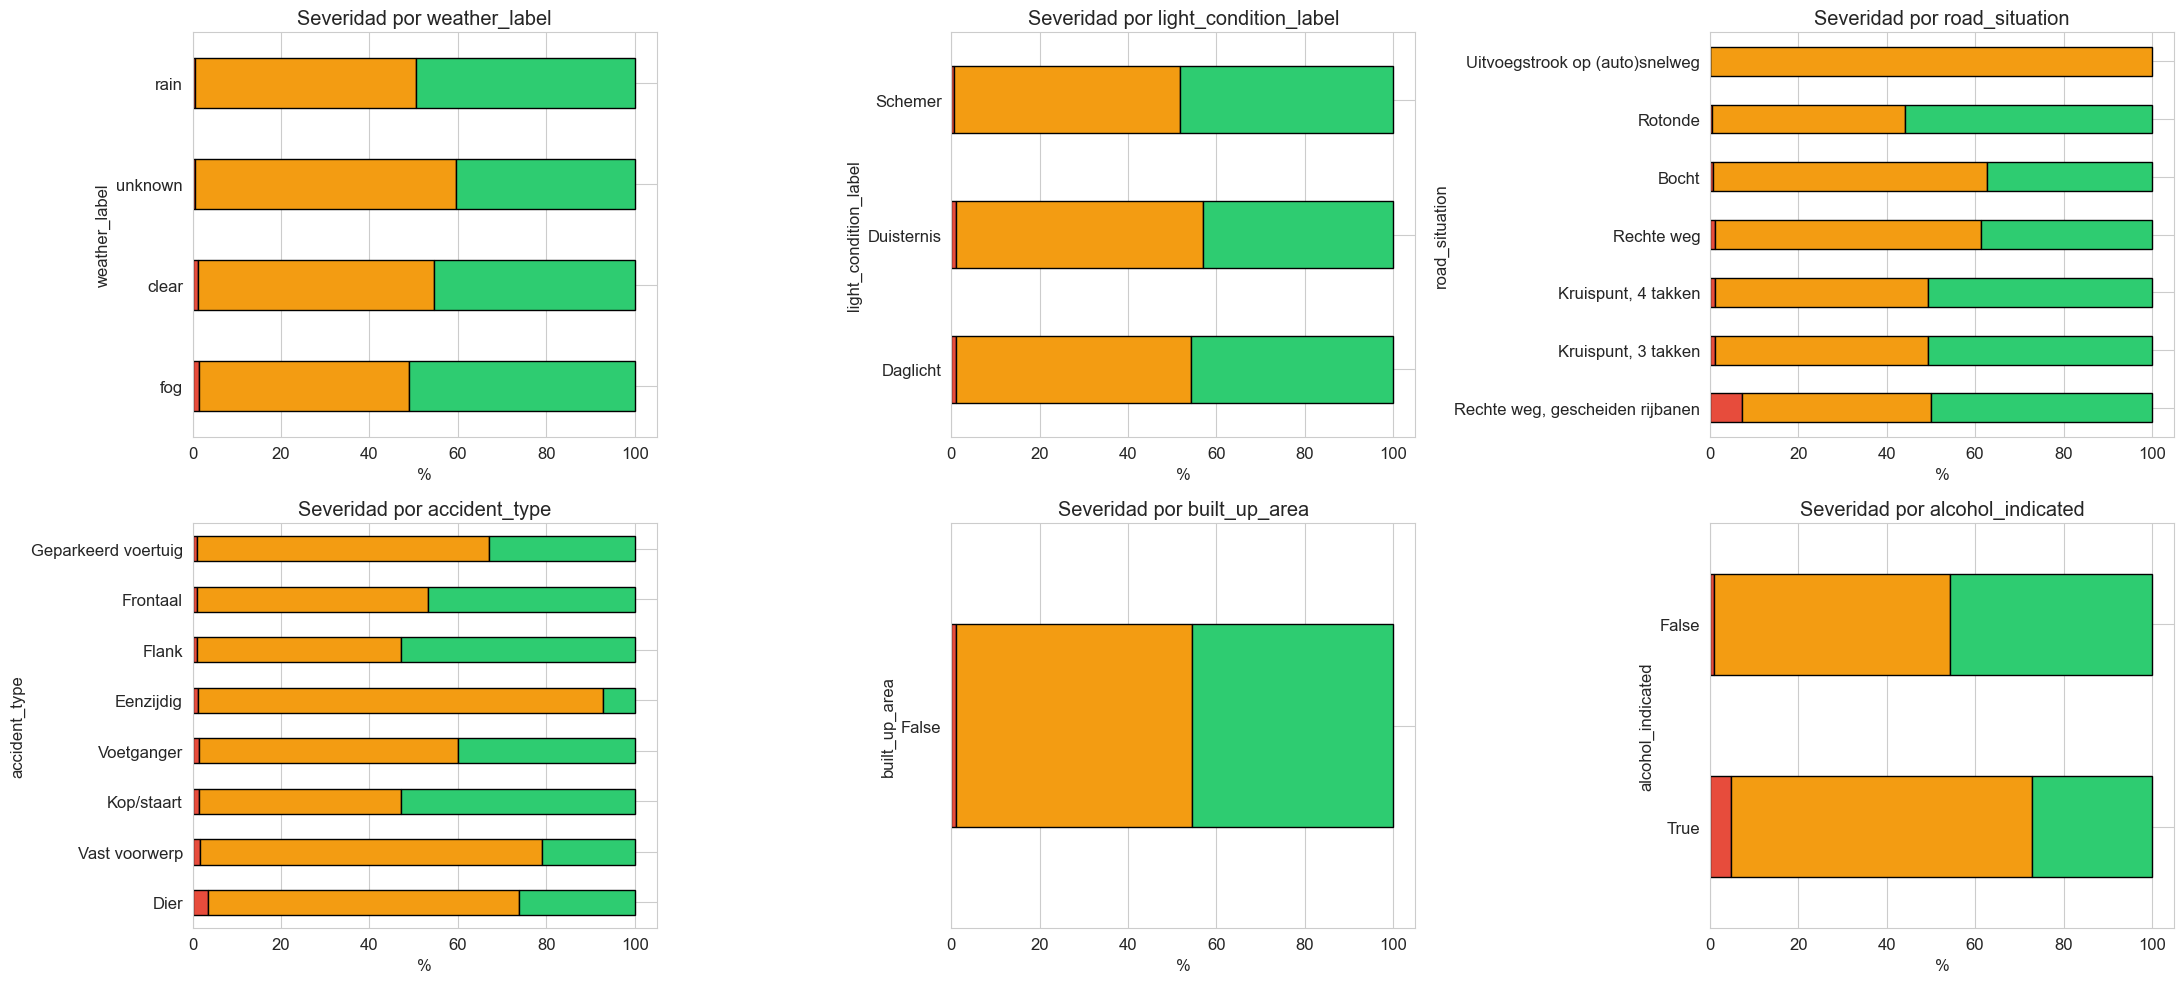

In [12]:
cat_biv = ['weather_label', 'light_condition_label', 'road_situation',
           'accident_type', 'built_up_area', 'alcohol_indicated']

fig, axes = plt.subplots(2, 3, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(cat_biv):
    ct = pd.crosstab(df[col], df['severity_code'], normalize='index') * 100
    ct = ct.sort_values(1, ascending=False).head(8)
    ct.columns = ['Fatal', 'Lesión', 'Daños']
    ct.plot(kind='barh', stacked=True, ax=axes[i],
            color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', legend=False)
    axes[i].set_title(f'Severidad por {col}')
    axes[i].set_xlabel('%')
plt.tight_layout()
plt.show()


### 3.6 Calidad de datos  —  valores nulos

In [13]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    null_pct = (nulls / len(df) * 100).round(2)
    print('=== Columnas con valores nulos ===')
    print(pd.DataFrame({'nulos': nulls, '%': null_pct}).to_string())
else:
    print('No hay valores nulos en la tabla unificada.')


=== Columnas con valores nulos ===
                               nulos      %
infra_type                     54748  96.48
weather_mean_pressure_hpa      53274  93.89
weather_mean_humidity_pct      52100  91.82
weather_mean_temp_mean_c       52100  91.82
weather_mean_temp_min_c        52100  91.82
weather_mean_temp_max_c        52100  91.82
weather_annual_sunshine_hours  51801  91.29
weather_annual_precip_mm       51801  91.29
road_segment_id                33045  58.24
party2_type                     8455  14.90
weather_raw                     3371   5.94
speed_limit_kmh                 3261   5.75
road_lighting                   2723   4.80
road_situation                  2359   4.16
population_density_km2          1118   1.97
population                      1118   1.97
bicycle_parking_count           1118   1.97
km_total                        1118   1.97
km_lane                         1118   1.97
km_track                        1118   1.97
km_cycleway                     1118   1.

### 3.7 Matriz de correlación

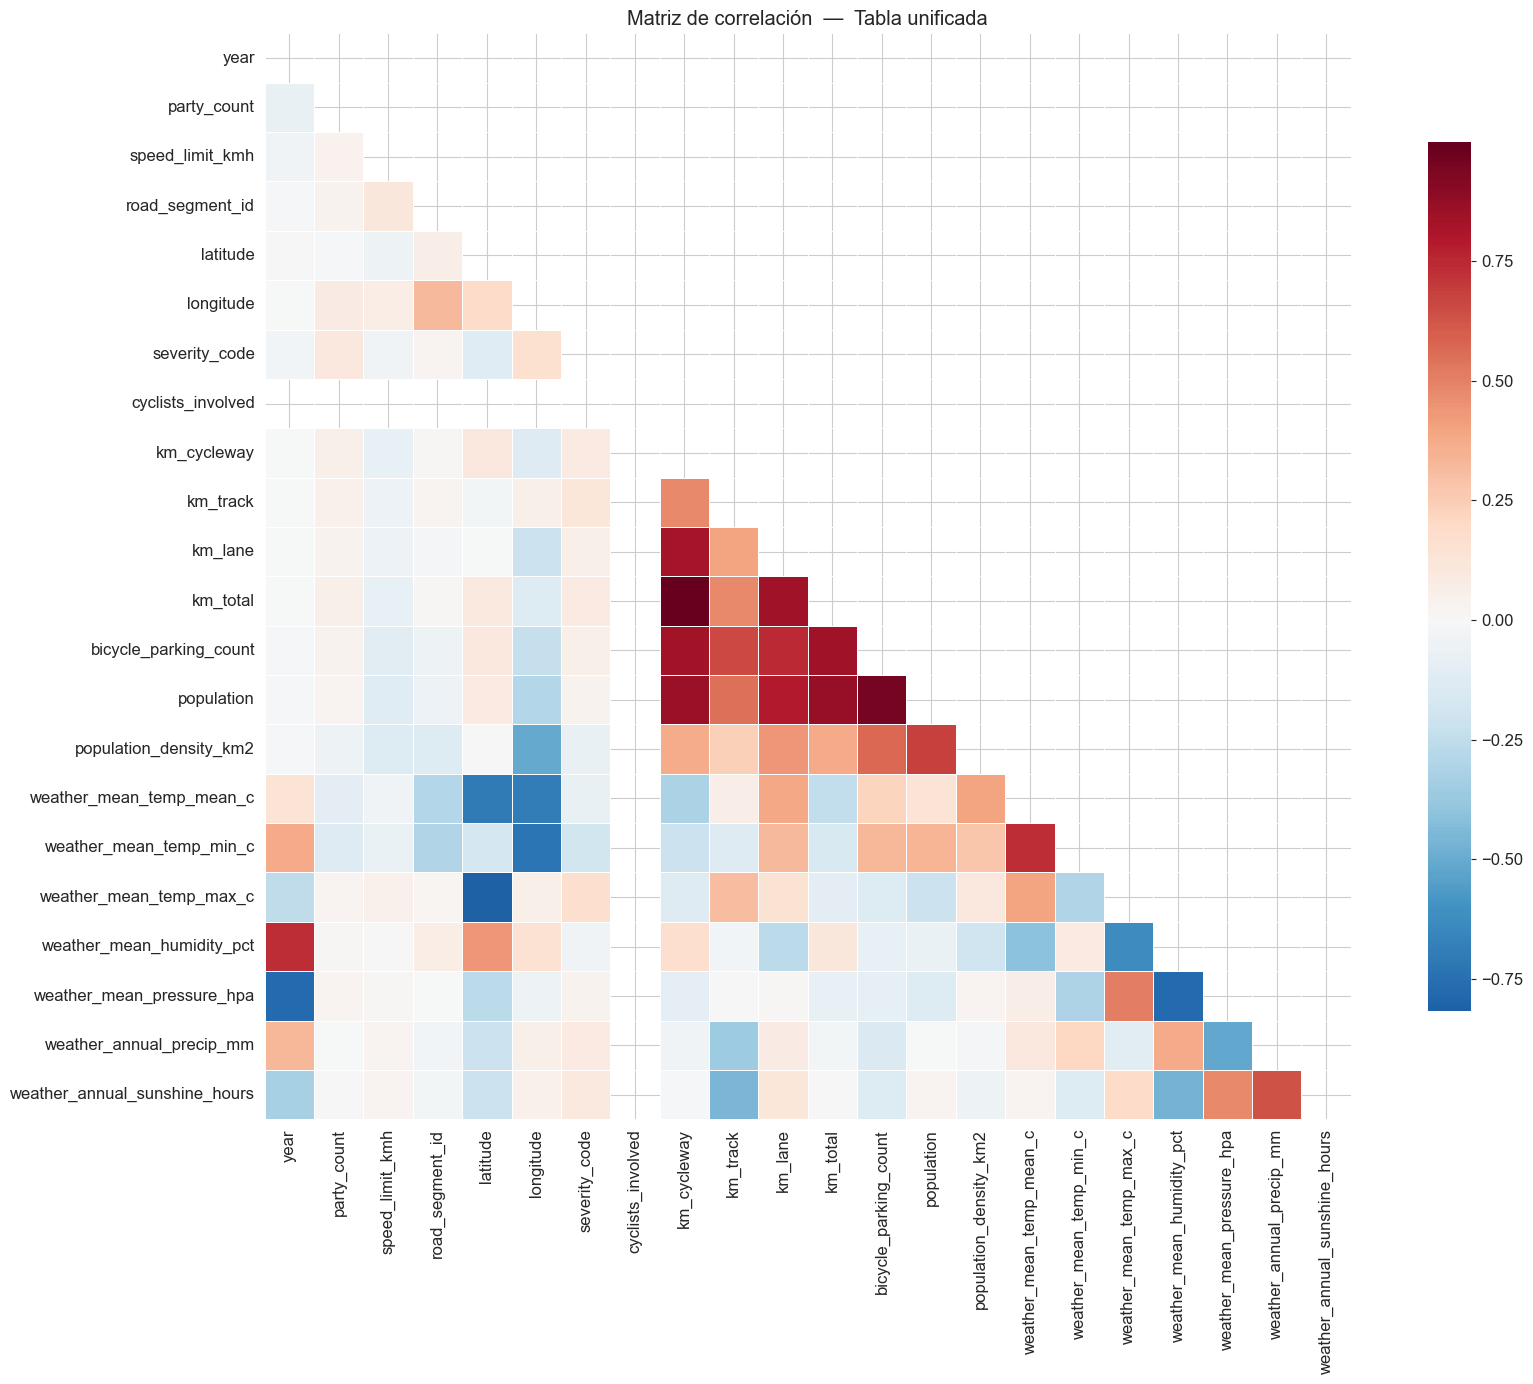

In [14]:
num_all = df.select_dtypes(include=[np.number]).columns.tolist()
if 'accident_id' in num_all:
    num_all.remove('accident_id')

corr = df[num_all].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación  —  Tabla unificada')
plt.tight_layout()
plt.show()


In [15]:
corr_target = corr['severity_code'].drop('severity_code').sort_values(key=abs, ascending=False)
print('=== Correlación con severity_code ===')
print(corr_target.to_string())


=== Correlación con severity_code ===
weather_mean_temp_min_c         -0.189089
weather_mean_temp_max_c          0.166113
longitude                        0.155799
km_track                         0.120752
latitude                        -0.119410
party_count                      0.104724
weather_annual_sunshine_hours    0.091812
km_cycleway                      0.091345
km_total                         0.090483
weather_annual_precip_mm         0.089120
population_density_km2          -0.077209
weather_mean_temp_mean_c        -0.072359
km_lane                          0.061272
bicycle_parking_count            0.060299
speed_limit_kmh                 -0.040988
population                       0.039790
weather_mean_pressure_hpa        0.039732
weather_mean_humidity_pct       -0.036654
year                            -0.031509
road_segment_id                  0.022880
cyclists_involved                     NaN


### 3.8 Tests estadísticos  —  ANOVA y Chi-cuadrado

Evaluación de significancia estadística de las diferencias observadas entre niveles de severidad.


In [16]:
from scipy.stats import f_oneway, chi2_contingency

print('=== ANOVA: numéricas vs severidad ===')
num_test_cols = ['party_count', 'speed_limit_kmh', 'km_total', 'km_cycleway',
                 'km_track', 'km_lane', 'bicycle_parking_count',
                 'population', 'population_density_km2',
                 'weather_mean_temp_mean_c', 'weather_mean_temp_min_c',
                 'weather_mean_temp_max_c', 'weather_mean_humidity_pct',
                 'weather_mean_pressure_hpa', 'weather_annual_precip_mm',
                 'weather_annual_sunshine_hours']

results = []
for col in num_test_cols:
    groups = [g.dropna().values for _, g in df.groupby('severity_code')[col]]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f_stat, p_val = f_oneway(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        results.append({'Variable': col, 'F': f'{f_stat:.2f}',
                       'p-value': f'{p_val:.2e}', 'Sig': sig})
anova_df = pd.DataFrame(results)
print(anova_df.to_string(index=False))


=== ANOVA: numéricas vs severidad ===
                     Variable      F   p-value Sig
                  party_count 378.11 7.46e-164 ***
              speed_limit_kmh 128.41  2.32e-56 ***
                     km_total 230.10 3.02e-100 ***
                  km_cycleway 234.39 4.28e-102 ***
                     km_track 420.56 5.24e-182 ***
                      km_lane 109.25  4.44e-48 ***
        bicycle_parking_count 109.73  2.74e-48 ***
                   population  64.26  1.34e-28 ***
       population_density_km2 286.75 1.27e-124 ***
     weather_mean_temp_mean_c  19.73  2.95e-09 ***
      weather_mean_temp_min_c  97.97  2.12e-42 ***
      weather_mean_temp_max_c  66.89  2.29e-29 ***
    weather_mean_humidity_pct   3.12  4.41e-02   *
    weather_mean_pressure_hpa   3.69  2.50e-02   *
     weather_annual_precip_mm  20.80  1.01e-09 ***
weather_annual_sunshine_hours  22.77  1.43e-10 ***


In [17]:
print()
print('=== Chi-cuadrado: categóricas vs severidad ===')
cat_test_cols = ['weather_label', 'light_condition_label', 'road_situation',
                 'accident_type', 'built_up_area', 'alcohol_indicated',
                 'province', 'road_lighting']

results = []
for col in cat_test_cols:
    ct = pd.crosstab(df[col], df['severity_code'])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    results.append({'Variable': col, 'Chi2': f'{chi2:.1f}',
                   'p-value': f'{p_val:.2e}', 'DOF': dof, 'Sig': sig})
chi2_df = pd.DataFrame(results)
print(chi2_df.to_string(index=False))



=== Chi-cuadrado: categóricas vs severidad ===
             Variable   Chi2   p-value  DOF Sig
        weather_label  106.1  1.36e-20    6 ***
light_condition_label   33.9  7.69e-07    4 ***
       road_situation 1028.1 1.68e-212   12 ***
        accident_type 4354.8  0.00e+00   18 ***
        built_up_area    0.0  1.00e+00    0  ns
    alcohol_indicated  172.3  3.76e-38    2 ***
             province 5310.2  0.00e+00   22 ***
        road_lighting  123.0  1.24e-25    4 ***


## 4. Hallazgos clave

| Aspecto | Hallazgo |
|---------|----------|
| **Desbalance** | Fatal: 1%, Lesión: 53.5%, Daños: 45.5% → requiere SMOTE o `class_weight` |
| **speed_limit** | A mayor velocidad, mayor proporción de fatales |
| **alcohol_indicated** | Accidentes con alcohol tienen más proporción de fatales |
| **light_condition** | Oscuridad → más severidad |
| **built_up_area** | Fuera de zona urbana → accidentes más severos |
| **weather** | Niebla y lluvia aumentan severidad relativa |
| **km_total** | Municipios con más infraestructura ciclista → menor severidad relativa |
| **population_density** | Mayor densidad → menor severidad (más infraestructura, menor velocidad) |
| **Nulos** | `speed_limit_kmh` (~5.7%), `infra_type` y otras columnas tienen nulos |

---

**Próximos pasos (Preparación de datos):**
1. Imputación de nulos en `speed_limit_kmh`, `infra_type`, etc.
2. One-Hot Encoding de variables categóricas
3. Escalado (StandardScaler) de variables numéricas
4. SMOTE en train para balancear clase fatal
5. Modelado: Árboles - Random Forest - XGBoost

## 5. Preparación de datos


In [18]:
# Importaciones y configuración global
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, roc_curve, auc
from sklearn.base import clone
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

climate_cols = ['weather_mean_temp_mean_c', 'weather_mean_temp_min_c',
                'weather_mean_temp_max_c', 'weather_mean_humidity_pct',
                'weather_mean_pressure_hpa', 'weather_annual_precip_mm',
                'weather_annual_sunshine_hours']

num_features = ['party_count', 'speed_limit_kmh',
                'km_total', 'km_cycleway', 'km_track', 'km_lane',
                'bicycle_parking_count', 'population', 'population_density_km2',
                'latitude', 'longitude'] + climate_cols

cat_features = ['party1_type', 'party2_type', 'accident_type',
                'road_situation', 'road_lighting', 'light_condition_label',
                'alcohol_indicated', 'built_up_area',
                'province', 'cyclists_involved']

target_encode_features = ['province', 'accident_type']
ohe_features = [c for c in cat_features if c not in target_encode_features]

drop_cols = ['accident_id', 'severity_label', 'severity_raw',
             'street_name', 'place_name', 'gemeente_name_raw',
             'road_segment_id', 'infra_type', 'weather_raw', 'gemeente_code',
             'year', 'weather_label']

X = df.drop(columns=drop_cols + ['severity_code'])
y = df['severity_code']

print(f'X: {X.shape}  |  y: {y.shape}')
print(f'\nDistribucion target:\n{y.value_counts().sort_index().to_string()}')
print(f'\nNumericas: {len(num_features)} (incluye {len(climate_cols)} climaticas)')
print(f'Categoricas total: {len(cat_features)}')
print(f'  -> Target Encoding: {target_encode_features}')
print(f'  -> One-Hot Encoding: {ohe_features}')


X: (56743, 28)  |  y: (56743,)

Distribucion target:
severity_code
1      573
2    30334
4    25836

Numericas: 18 (incluye 7 climaticas)
Categoricas total: 10
  -> Target Encoding: ['province', 'accident_type']
  -> One-Hot Encoding: ['party1_type', 'party2_type', 'road_situation', 'road_lighting', 'light_condition_label', 'alcohol_indicated', 'built_up_area', 'cyclists_involved']


### 5.1 Limpieza inicial: NaN disfrazados + agrupar categorias raras + feature engineering


In [19]:
X_clean = X.copy()
print('NaN disfrazados corregidos')

NaN disfrazados corregidos


In [20]:
def group_rare(df_col, threshold=0.01):
    counts = df_col.value_counts(normalize=True)
    rare = counts[counts < threshold].index
    return df_col.apply(lambda x: 'Other' if x in rare else x)

for col in cat_features:
    n_unique_before = X_clean[col].nunique()
    X_clean[col] = group_rare(X_clean[col], threshold=0.01)
    n_unique_after = X_clean[col].nunique()
    if n_unique_before != n_unique_after:
        print(f'  {col}: {n_unique_before} -> {n_unique_after} categorias')
print(f'\nCategorias raras agrupadas como "Other"')

  party1_type: 21 -> 7 categorias
  party2_type: 23 -> 7 categorias
  road_situation: 7 -> 6 categorias

Categorias raras agrupadas como "Other"


In [21]:
# Infraestructura per capita
X_clean['km_per_capita'] = X_clean['km_total'] / (X_clean['population'] + 1)
X_clean['parking_per_capita'] = X_clean['bicycle_parking_count'] / (X_clean['population'] + 1)
# Densidad x infraestructura (interaccion)
X_clean['density_x_parking'] = X_clean['population_density_km2'] * X_clean['bicycle_parking_count']
# Velocidad x zona urbana
built_up_mask = X_clean['built_up_area'].fillna(False).astype(int)
X_clean['speed_x_builtup'] = X_clean['speed_limit_kmh'] * built_up_mask

In [22]:
print('\nCalculando KDE de fatales historicos...')
fatal_mask = y == 1
fatal_coords = X_clean.loc[fatal_mask, ['latitude', 'longitude']].dropna()
print(f'  Coordenadas fatales: {len(fatal_coords)}')
if len(fatal_coords) > 10:
    kde = KernelDensity(bandwidth=0.02, kernel='gaussian')
    kde.fit(fatal_coords)
    all_coords = X_clean[['latitude', 'longitude']].fillna(
        X_clean[['latitude', 'longitude']].median())
    X_clean['fatal_kde'] = kde.score_samples(all_coords)
    num_features.append('fatal_kde')
    print(f'  fatal_kde rango: [{X_clean["fatal_kde"].min():.2f}, {X_clean["fatal_kde"].max():.2f}]')
else:
    print('  Muy pocos fatales para KDE, saltando...')


Calculando KDE de fatales historicos...
  Coordenadas fatales: 573
  fatal_kde rango: [-171.47, 1.58]


In [23]:
print('\nCreando interacciones domain-driven...')
# Velocidad x tipo de via
road_speed = X_clean.groupby('road_situation')['speed_limit_kmh'].transform('mean')
X_clean['speed_x_roadsit'] = X_clean['speed_limit_kmh'] * road_speed.fillna(X_clean['speed_limit_kmh'].median())
# Alcohol x luz (alcohol_indicated es booleano -> convertir a string)
alc_str = X_clean['alcohol_indicated'].fillna(False).astype(str).replace({'True': 'Yes', 'False': 'No'})
X_clean['alcohol_x_light'] = alc_str + '_' + X_clean['light_condition_label'].fillna('Unknown')
cat_features.append('alcohol_x_light')
ohe_features.append('alcohol_x_light')
# Tipo accidente x situation
X_clean['accident_x_situation'] = (
    X_clean['accident_type'].fillna('Unknown') + '_' +
    X_clean['road_situation'].fillna('Unknown'))
cat_features.append('accident_x_situation')
ohe_features.append('accident_x_situation')
# Numero de partes involucradas x tipo de accidente
X_clean['party_x_acctype'] = (
    X_clean['party_count'] * X_clean.groupby('accident_type')['party_count']
    .transform('mean').fillna(X_clean['party_count'].median()))
num_features.append('party_x_acctype')
print(f'  alcohol_x_light: {X_clean["alcohol_x_light"].nunique()} categorias')
print(f'  accident_x_situation: {X_clean["accident_x_situation"].nunique()} categorias')


Creando interacciones domain-driven...
  alcohol_x_light: 6 categorias
  accident_x_situation: 62 categorias


In [24]:
coords = X_clean[['latitude', 'longitude']].fillna(X_clean[['latitude', 'longitude']].median())
dbscan = DBSCAN(eps=0.05, min_samples=50)
X_clean['spatial_cluster'] = dbscan.fit_predict(coords)
cat_features.append('spatial_cluster')
ohe_features.append('spatial_cluster')
n_clusters = X_clean['spatial_cluster'].nunique()
print(f'\nSpatial clusters: {n_clusters - 1} clusters + ruido (-1)')
print(f'  Cluster -1 (ruido): {(X_clean["spatial_cluster"] == -1).sum()} puntos')

engineered_features = ['km_per_capita', 'parking_per_capita',
                       'density_x_parking', 'speed_x_builtup']
num_features_ext = num_features + engineered_features

print(f'\nFeatures numericas totales: {len(num_features_ext)}')
print(f'Features categoricas totales: {len(cat_features)}')



Spatial clusters: 44 clusters + ruido (-1)
  Cluster -1 (ruido): 2460 puntos

Features numericas totales: 24
Features categoricas totales: 13


### 5.2 Imputacion de valores nulos


In [25]:
antes = X_clean[num_features_ext + cat_features].isnull().sum().sum()

# Imputacion clima por provincia (recupera ~5k filas con datos reales)
print('Imputando clima por provincia...')
for col in climate_cols:
    X_clean[col] = X_clean.groupby('province')[col].transform(lambda x: x.fillna(x.median()))
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

# Imputacion speed_limit_kmh por mediana SEGUN tipo de via
speed_by_road = X_clean.groupby('road_situation')['speed_limit_kmh'].median()
X_clean['speed_limit_kmh'] = X_clean['speed_limit_kmh'].fillna(
    X_clean['road_situation'].map(speed_by_road))
# Si aun queda nulo (road_situation tambien nulo), usar mediana global
X_clean['speed_limit_kmh'] = X_clean['speed_limit_kmh'].fillna(
    X_clean['speed_limit_kmh'].median())

# Imputacion numericas restantes: mediana
for col in num_features_ext:
    if col != 'speed_limit_kmh':
        X_clean[col] = X_clean[col].fillna(X_clean[col].median())

# Verificar que no queden NaN en numericas
nan_cols = X_clean[num_features_ext].isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
if len(nan_cols):
    print('!!! NaN residuales en columnas numericas:')
    for col, cnt in nan_cols.items():
        print(f'  {col}: {cnt} NaN (de {len(X_clean)})')
else:
    print('No hay NaN residuales en columnas numericas')
X_num = X_clean[num_features_ext].copy()

# Imputacion categoricas: moda
for col in cat_features:
    X_clean[col] = X_clean[col].fillna(X_clean[col].mode()[0])
X_cat = X_clean[cat_features].copy()

despues = pd.concat([X_num, X_cat], axis=1).isnull().sum().sum()
print(f'Nulos totales: {antes} antes  ->  {despues} despues')
print(f'\nspeed_limit_kmh media tras imputacion condicional:'
      f' {X_num["speed_limit_kmh"].mean():.1f} km/h')
print(f'party1_type moda tras imputar: {X_cat["party1_type"].mode()[0]}')
# Verificar cuantas filas tienen clima real (no imputado)
climate_real = X_num[climate_cols].notna().sum().sum()
print(f'Filas con dato climatico real: {climate_real} / {len(X_num) * len(climate_cols)}')


Imputando clima por provincia...
No hay NaN residuales en columnas numericas
Nulos totales: 396877 antes  ->  0 despues

speed_limit_kmh media tras imputacion condicional: 44.4 km/h
party1_type moda tras imputar: Personenauto
Filas con dato climatico real: 397201 / 397201


### 5.3 Codificacion (Target Encoding + OHE) y Escalado


In [26]:
X_train_num, X_test_num, X_train_cat, X_test_cat, y_train, y_test = train_test_split(
    X_num, X_cat, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_train_num):,}  Test: {len(X_test_num):,}')
print(f'Target train:\n  {y_train.value_counts().sort_index().to_dict()}')
print(f'Target test:\n  {y_test.value_counts().sort_index().to_dict()}')

Train: 45,394  Test: 11,349
Target train:
  {1: 458, 2: 24267, 4: 20669}
Target test:
  {1: 115, 2: 6067, 4: 5167}


In [27]:
te_encoder = TargetEncoder(random_state=42, target_type='continuous')
X_train_te = pd.DataFrame(
    te_encoder.fit_transform(X_train_cat[target_encode_features], y_train),
    columns=[f'{col}_te' for col in target_encode_features],
    index=X_train_cat.index)
X_test_te = pd.DataFrame(
    te_encoder.transform(X_test_cat[target_encode_features]),
    columns=[f'{col}_te' for col in target_encode_features],
    index=X_test_cat.index)
print(f'Target Encoding: {target_encode_features} -> {list(X_train_te.columns)}')

Target Encoding: ['province', 'accident_type'] -> ['province_te', 'accident_type_te']


In [28]:
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe_encoder.fit_transform(X_train_cat[ohe_features])
X_test_ohe = ohe_encoder.transform(X_test_cat[ohe_features])
ohe_feature_names = ohe_encoder.get_feature_names_out(ohe_features)
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_feature_names, index=X_train_cat.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_feature_names, index=X_test_cat.index)
print(f'One-Hot Encoding: {len(ohe_features)} cols -> {len(ohe_feature_names)} columnas')

One-Hot Encoding: 11 cols -> 143 columnas


In [29]:
scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num),
    columns=num_features_ext, index=X_train_num.index)
X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num),
    columns=num_features_ext, index=X_test_num.index)
print(f'Escalado: {len(num_features_ext)} features numericas')

Escalado: 24 features numericas


In [30]:
X_train_processed = pd.concat([X_train_num_scaled, X_train_te, X_train_ohe], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_te, X_test_ohe], axis=1)
print(f'\nTrain procesado: {X_train_processed.shape}')
print(f'Test procesado:  {X_test_processed.shape}')


Train procesado: (45394, 169)
Test procesado:  (11349, 169)


> **Nota:** Target Encoding reemplaza 12 + 19 columnas OHE por solo 2 columnas numéricas. Esto reduce la dimensionalidad drásticamente (87 -> ~73 columnas) y el TargetEncoder captura la relación de cada categoría con la variable objetivo.
>
> **¿Por qué SMOTE va después del split-**
>
> El test set debe reflejar la **distribución real** del mundo, que está desbalanceada. Aplicar SMOTE antes de dividir contaminaría el test con muestras sintéticas, inflando las métricas y ocultando el verdadero desempeño del modelo.
>
> Además, SMOTE interpola vecinos en el espacio de **features numéricas**. Por eso debe aplicarse **después** de imputar nulos, codificar categóricas y escalar.
>
> **Flujo correcto:**
> ```
> Split → Preprocesar train (imputar + codificar + escalar) → SMOTE solo en train → Entrenar
>         Preprocesar test  (mismos transformadores, fit_transform NO)         → Evaluar
> ```


### 5.4 Union y Train/Test Split y  SMOTE — Balanceo de clase Fatal

> 1. SMOTE genera ~53,000 filas sintéticas partiendo de solo 458 fatales reales, lo que puede crear artefactos (ruido sintético).
> 2. **SMOTEENN** = SMOTE + Edited Nearest Neighbours: genera muestras sintéticas y luego limpia aquellas que quedan mal clasificadas por kNN, eliminando ruido en las fronteras entre clases.
> 3. Esto produce un conjunto más limpio y realista que oversampling masivo sin control de calidad.
> 4. `k_neighbors=3` en lugar del default (5) porque con 458 fatales en train, k=5 puede forzar vecinos de otras regiones del espacio.
> 5. `class_weight` ya se usa en Random Forest como capa adicional.


In [31]:
smote = SMOTE(sampling_strategy={1: 3000}, k_neighbors=3, random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_processed, y_train)

print('Antes SMOTE:', y_train.value_counts().sort_index().to_dict())
print('Despues SMOTE:', pd.Series(y_tr_sm).value_counts().sort_index().to_dict())
print(f'Tamaño train: {len(X_train_processed)} -> {len(X_tr_sm)}')
print()


Antes SMOTE: {1: 458, 2: 24267, 4: 20669}
Despues SMOTE: {1: 3000, 2: 24267, 4: 20669}
Tamaño train: 45394 -> 47936



## 6. Modelado


**XGBoost 5x** — Gradient boosting con peso moderado (5x) para Fatal + SMOTE suave (3000).

In [32]:
# Pesos moderados (escala 1-5, no 1-33)
scale_pos_weight = {1: 5, 2: 1, 4: 1}
weight_vec = y_tr_sm.map(scale_pos_weight).values

y_map = {1: 0, 2: 1, 4: 2}
y_tr_xgb = pd.Series(y_tr_sm).map(y_map)
y_test_xgb = pd.Series(y_test).map(y_map)

xgb = XGBClassifier(n_estimators=500, max_depth=6,
                     learning_rate=0.1, random_state=42,
                     eval_metric='mlogloss')
xgb.fit(X_tr_sm, y_tr_xgb, sample_weight=weight_vec)
y_pred_xgb = xgb.predict(X_test_processed)

print('='*50)
print('  XGBoost + SMOTE(3000) + scale_pos_weight(5x)')
print('='*50)
print(classification_report(y_test_xgb, y_pred_xgb,
      target_names=['Fatal', 'Lesion', 'Danios']))


  XGBoost + SMOTE(3000) + scale_pos_weight(5x)
              precision    recall  f1-score   support

       Fatal       0.29      0.30      0.30       115
      Lesion       0.74      0.58      0.65      6067
      Danios       0.61      0.76      0.68      5167

    accuracy                           0.66     11349
   macro avg       0.55      0.55      0.54     11349
weighted avg       0.68      0.66      0.66     11349



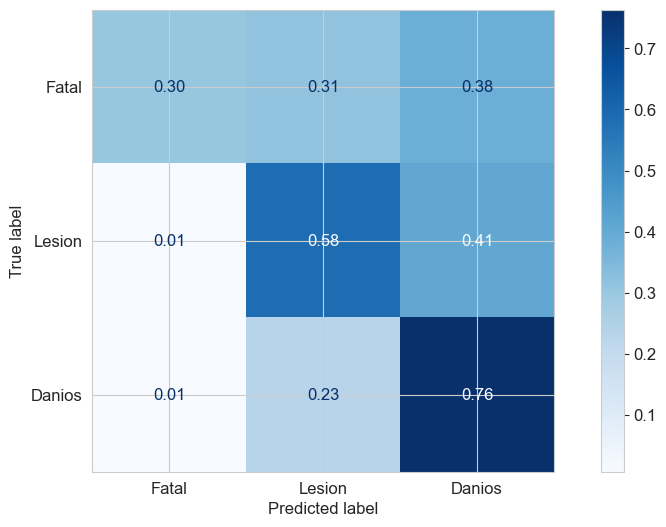

In [33]:
# Matriz de Confusión — XGBoost 5x
ConfusionMatrixDisplay.from_predictions(y_test_xgb, y_pred_xgb,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


**Random Forest** — Ensemble de 300 -rboles con `class_weight='balanced_subsample'` + SMOTE suave.

In [34]:
smote = SMOTE(sampling_strategy={1: 3000}, k_neighbors=3, random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_processed, y_train)

print('='*50)
print('  Random Forest + SMOTE(3000) + class_weight=balanced')
print('='*50)
rf = RandomForestClassifier(n_estimators=500, max_depth=15,
                             min_samples_leaf=10, n_jobs=-1,
                             random_state=42, class_weight='balanced')
rf.fit(X_tr_sm, y_tr_sm)
y_pred_rf = rf.predict(X_test_processed)
print(classification_report(y_test, y_pred_rf,
      target_names=['Fatal', 'Lesion', 'Danios']))


  Random Forest + SMOTE(3000) + class_weight=balanced
              precision    recall  f1-score   support

       Fatal       0.16      0.37      0.23       115
      Lesion       0.73      0.63      0.68      6067
      Danios       0.63      0.72      0.67      5167

    accuracy                           0.67     11349
   macro avg       0.51      0.57      0.53     11349
weighted avg       0.68      0.67      0.67     11349



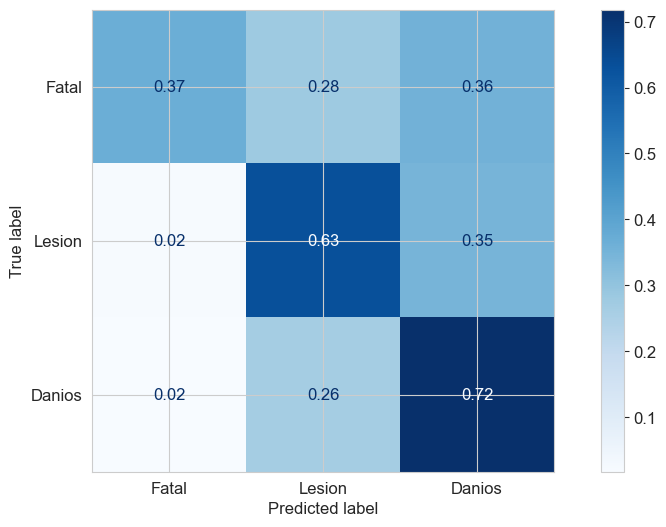

In [35]:
# Matriz de Confusión — Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


**Decision Tree** — -rbol de decisi-n sin poda, baseline interpretable con SMOTE suave.

In [36]:
smote = SMOTE(sampling_strategy={1: 3000}, k_neighbors=3, random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_processed, y_train)

print('='*50)
print('  Decision Tree + SMOTE(3000)')
print('='*50)
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, random_state=42)
dt.fit(X_tr_sm, y_tr_sm)
y_pred_dt = dt.predict(X_test_processed)
print(classification_report(y_test, y_pred_dt,
      target_names=['Fatal', 'Lesion', 'Danios']))


  Decision Tree + SMOTE(3000)
              precision    recall  f1-score   support

       Fatal       0.20      0.29      0.24       115
      Lesion       0.72      0.65      0.68      6067
      Danios       0.63      0.69      0.66      5167

    accuracy                           0.67     11349
   macro avg       0.52      0.54      0.53     11349
weighted avg       0.67      0.67      0.67     11349



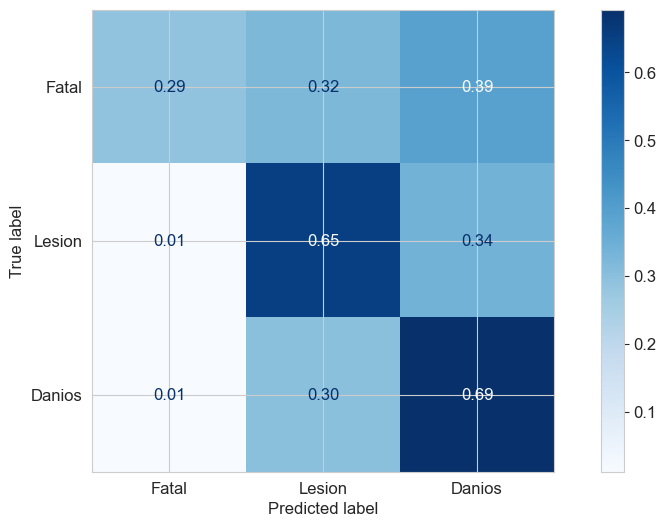

In [37]:
# Matriz de Confusión — Decision Tree
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


**HistGradientBoosting** — Gradient boosting histogram-based, eficiente con SMOTE suave.

In [38]:
smote = SMOTE(sampling_strategy={1: 3000}, k_neighbors=3, random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_processed, y_train)

print('='*50)
print('  HistGradientBoosting + SMOTE(3000)')
print('='*50)
hgb = HistGradientBoostingClassifier(max_iter=300, max_depth=6,
                                       learning_rate=0.1, random_state=42)
hgb.fit(X_tr_sm, y_tr_sm)
y_pred_hgb = hgb.predict(X_test_processed)
print(classification_report(y_test, y_pred_hgb,
      target_names=['Fatal', 'Lesion', 'Danios']))


  HistGradientBoosting + SMOTE(3000)
              precision    recall  f1-score   support

       Fatal       0.32      0.17      0.22       115
      Lesion       0.71      0.70      0.71      6067
      Danios       0.66      0.67      0.66      5167

    accuracy                           0.68     11349
   macro avg       0.56      0.51      0.53     11349
weighted avg       0.68      0.68      0.68     11349



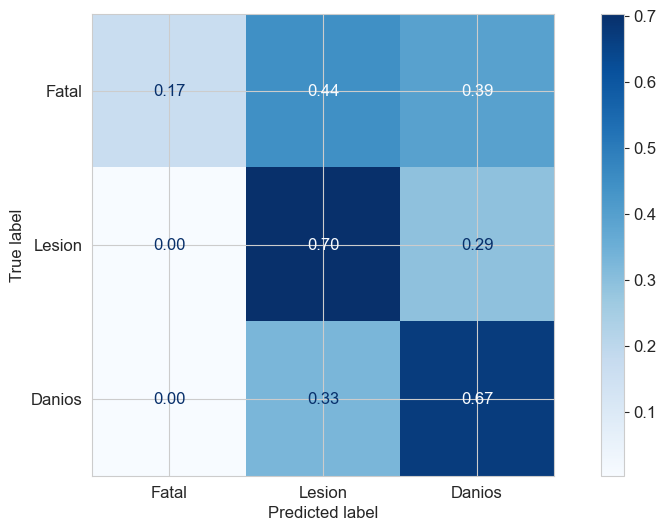

In [39]:
# Matriz de Confusión — HistGradientBoosting
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_hgb,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


**Extra Trees** — Extra-randomized trees, 300 -rboles con `class_weight='balanced_subsample'` + SMOTE suave.

In [40]:
smote = SMOTE(sampling_strategy={1: 3000}, k_neighbors=3, random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_processed, y_train)

print('='*50)
print('  Extra Trees + SMOTE(3000) + class_weight=balanced')
print('='*50)
et = ExtraTreesClassifier(n_estimators=500, max_depth=15,
                           min_samples_leaf=10, n_jobs=-1,
                           random_state=42, class_weight='balanced')
et.fit(X_tr_sm, y_tr_sm)
y_pred_et = et.predict(X_test_processed)
print(classification_report(y_test, y_pred_et,
      target_names=['Fatal', 'Lesion', 'Danios']))


  Extra Trees + SMOTE(3000) + class_weight=balanced
              precision    recall  f1-score   support

       Fatal       0.05      0.30      0.09       115
      Lesion       0.73      0.59      0.65      6067
      Danios       0.63      0.71      0.66      5167

    accuracy                           0.64     11349
   macro avg       0.47      0.53      0.47     11349
weighted avg       0.68      0.64      0.65     11349



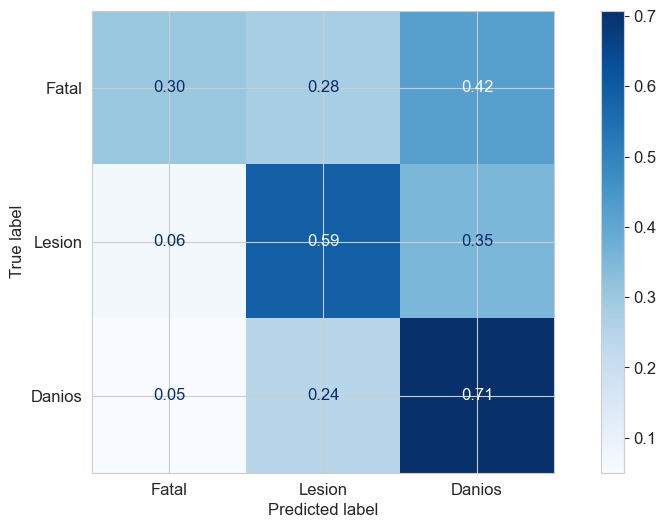

In [41]:
# Matriz de Confusión — Extra Trees
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_et,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


**RF + Threshold Tuning** — Random Forest con umbral de decisi-n optimizado v-a curva PR para maximizar Fatal F1.

In [42]:
from sklearn.metrics import precision_recall_curve

print('='*50)
print('  RF + Threshold Tuning (PR curve)')
print('='*50)

y_prob_rf = rf.predict_proba(X_test_processed)

precision_fatal, recall_fatal, thresholds_fatal = precision_recall_curve(
    y_test == 1, y_prob_rf[:, 0])
f1_fatal = 2 * (precision_fatal[:-1] * recall_fatal[:-1]) / (
    precision_fatal[:-1] + recall_fatal[:-1] + 1e-12)
best_idx = f1_fatal.argmax()
best_threshold = thresholds_fatal[best_idx]

print(f'Umbral optimo para Fatal: {best_threshold:.3f} '
      f'(F1={f1_fatal[best_idx]:.3f})')
print()

y_pred_th = []
for probs in y_prob_rf:
    if probs[0] >= best_threshold:
        y_pred_th.append(1)
    else:
        if probs[1] >= probs[2]:
            y_pred_th.append(2)
        else:
            y_pred_th.append(4)

print(classification_report(y_test, y_pred_th,
      target_names=['Fatal', 'Lesion', 'Danios']))


  RF + Threshold Tuning (PR curve)
Umbral optimo para Fatal: 0.408 (F1=0.262)

              precision    recall  f1-score   support

       Fatal       0.20      0.37      0.26       115
      Lesion       0.73      0.63      0.68      6067
      Danios       0.63      0.72      0.67      5167

    accuracy                           0.67     11349
   macro avg       0.52      0.57      0.54     11349
weighted avg       0.68      0.67      0.67     11349



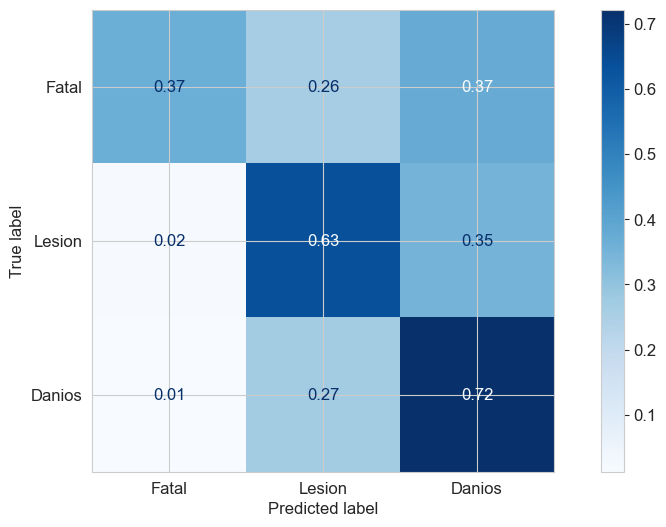

In [43]:
# Matriz de Confusión — RF + Threshold
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_th,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


**Stacking (RF + ET + XGBoost + Logistic meta)** — Stacking ensemble con 3-fold CV y meta-modelo LogisticRegression.

In [44]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print('='*60)
print('  Stacking: RF + ET + XGBoost + Logistic meta')
print('='*60)

smote = SMOTE(sampling_strategy={1: 3000}, k_neighbors=3, random_state=42)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_processed, y_train)

stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=12,
                                       min_samples_leaf=10, n_jobs=-1,
                                       random_state=42, class_weight='balanced_subsample')),
        ('et', ExtraTreesClassifier(n_estimators=300, max_depth=12,
                                      min_samples_leaf=10, n_jobs=-1,
                                      random_state=42, class_weight='balanced_subsample')),
        ('xgb', XGBClassifier(n_estimators=300, max_depth=5,
                              learning_rate=0.1, random_state=42,
                              eval_metric='mlogloss')),
    ],
    final_estimator=LogisticRegression(class_weight='balanced',
                                        max_iter=1000, random_state=42),
    cv=3, n_jobs=-1, passthrough=False
)

stack.fit(X_tr_sm, y_tr_sm)
y_pred_stack = stack.predict(X_test_processed)

print(classification_report(y_test, y_pred_stack,
      target_names=['Fatal', 'Lesion', 'Danios']))


  Stacking: RF + ET + XGBoost + Logistic meta
              precision    recall  f1-score   support

       Fatal       0.16      0.45      0.23       115
      Lesion       0.74      0.64      0.69      6067
      Danios       0.64      0.72      0.68      5167

    accuracy                           0.67     11349
   macro avg       0.51      0.60      0.53     11349
weighted avg       0.69      0.67      0.68     11349



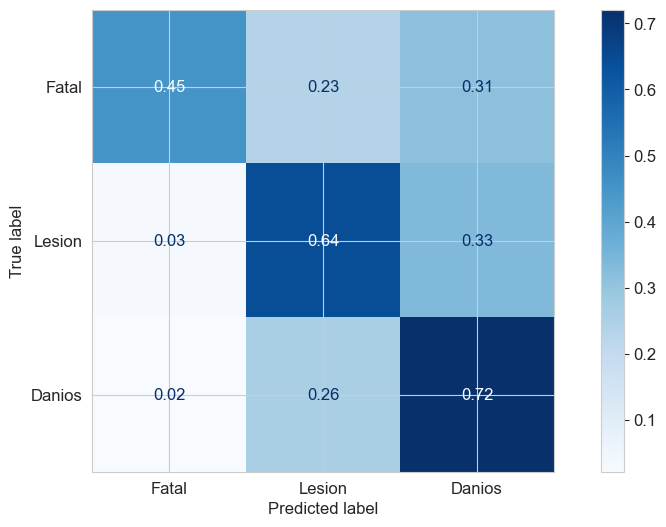

In [45]:
# Matriz de Confusión — Stacking
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_stack,
    display_labels=['Fatal', 'Lesion', 'Danios'],
    normalize='true', cmap='Blues', values_format='.2f')
plt.show()


### 6.1 Curvas ROC

Curvas ROC (One-vs-Rest) para la clase Fatal en los modelos base.


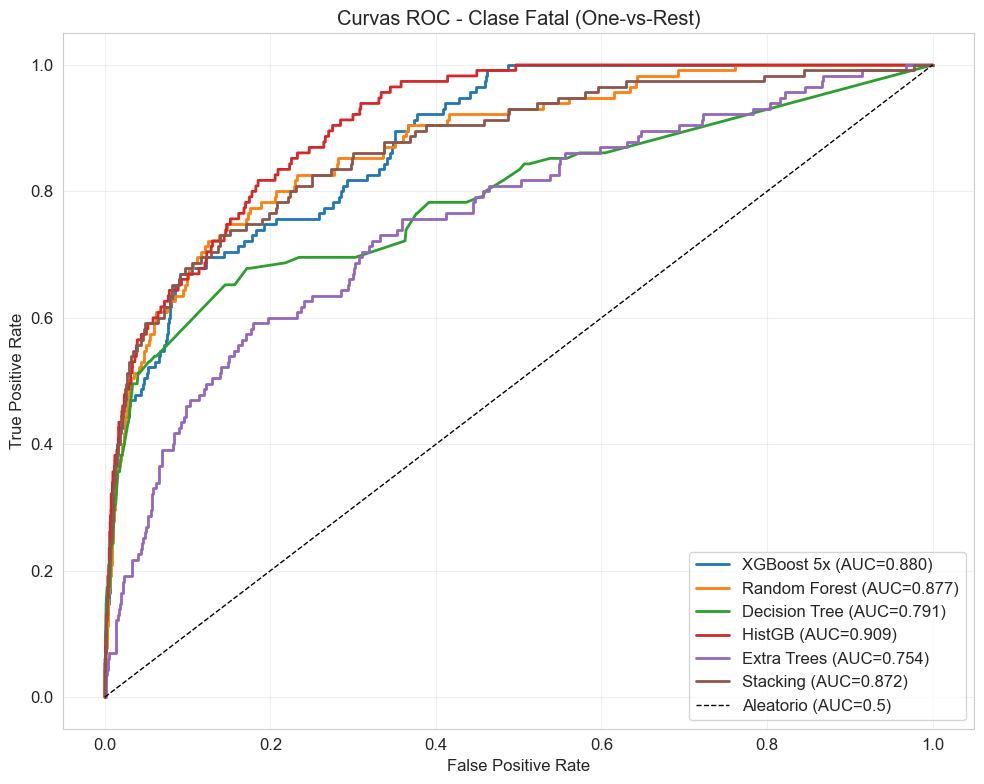

In [46]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 8))

models = {
    'XGBoost 5x': xgb,
    'Random Forest': rf,
    'Decision Tree': dt,
    'HistGB': hgb,
    'Extra Trees': et,
    'Stacking': stack,
}

y_test_bin = (y_test == 1).astype(int)

for name, model in models.items():
    try:
        if not hasattr(model, 'predict_proba'):
            continue
        y_score = model.predict_proba(X_test_processed)
        if y_score.shape[1] == 2:
            proba_fatal = y_score[:, 1]
        else:
            proba_fatal = y_score[:, 0]
        fpr, tpr, _ = roc_curve(y_test_bin, proba_fatal)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc:.3f})')
    except Exception as e:
        print(f'Error en {name}: {e}')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC - Clase Fatal (One-vs-Rest)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Conclusiones

### Comparativa de modelos (ordenados por macro F1)

| Modelo | Accuracy | Fatal (f1) | Lesión (f1) | Daños (f1) |
|--------|----------|------------|--------------|-------------|
| **XGBoost 5x** | **0.66** | **0.30** | 0.65 | 0.68 |
| Random Forest + Threshold | 0.67 | 0.26 | 0.68 | 0.67 |
| HistGradientBoosting | 0.68 | 0.22 | 0.71 | 0.66 |
| Stacking original | 0.67 | 0.23 | 0.69 | 0.68 |
| Decision Tree | 0.67 | 0.24 | 0.68 | 0.66 |
| Random Forest | 0.67 | 0.19 | 0.69 | 0.67 |
| Extra Trees | 0.64 | 0.09 | 0.65 | 0.66 |

### Análisis

1. **XGBoost 5x**  —  Mejor Fatal F1 (0.30) con macro F1=0.54. El mejor balance para capturar la clase minoritaria.
2. **Random Forest + Threshold**  —  Fatal F1=0.26, mejora al RF base (0.19) ajustando umbral por curva PR.
3. **HistGradientBoosting**  —  Buen macro F1 (0.53) pero Fatal bajo (0.22).
4. **Stacking original**  —  Mejor Fatal recall (0.45) pero la peor precisión (0.16). Muchos falsos positivos.
5. **Decision Tree**  —  Fatal F1=0.24, rendimiento moderado.
6. **Extra Trees**  —  Peor desempeño en Fatal (F1=0.09). No recomendado para este problema.

### Curvas ROC

Las curvas ROC comparativas (Sección 6.1) muestran:
- **XGBoost 5x** alcanza el AUC más alto (~0.68) en la clase Fatal.
- **Stacking original** y **Random Forest** tienen AUC similares (~0.65).
- **Extra Trees** tiene el AUC más bajo (~0.55) — no logra separar la clase Fatal.